# Lab Session: Introduction to NumPy

**Objective:**
By the end of this lab, you will:
- Understand the rationale behind NumPy and its advantages over basic Python.
- Learn about NumPy arrays and vectorization.
- Explore basic NumPy operations, including ufuncs and masking.

---

In [20]:
!pip install numpy matplotlib seaborn

## 1. Introduction to NumPy

### 1.1 What is NumPy?
NumPy (Numerical Python) is the fundamental package for scientific computing in Python. It provides support for large, multi-dimensional arrays and matrices, along with a collection of mathematical functions.

**Key Features:**
- **Efficiency:** NumPy arrays are stored more compactly than Python lists, leading to faster computations.
- **Vectorization:** Allows operations on entire arrays without writing explicit loops.

### 1.2 Why Use NumPy?
- **Performance:** NumPy operations are implemented in C, making them much faster than equivalent Python code.

---

In [ ]:
# Core imports
import time

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### **Exercise 1: Basic Array Creation**
Create a 1D NumPy array named `data_vector` containing the integers 5, 10, 15, 20, and a $3 \times 3$ array named `identity_matrix` filled with ones.

In [22]:
# Create data_vector
data_vector = np.array([5, 10, 15, 20])
print("Data Vector:", data_vector)

# Create identity_matrix (using np.ones)
identity_matrix = np.ones((3, 3), dtype=int)
print("Identity Matrix:\n", identity_matrix)

Data Vector: [ 5 10 15 20]
Identity Matrix:
 [[1 1 1]
 [1 1 1]
 [1 1 1]]


You can inspect the shape of the array using both the ```.ndim``` attribute or the ```.shape``` attribute. 

In [23]:

print(identity_matrix.ndim)

2


In [24]:
print(identity_matrix.shape)

(3, 3)


## 2. The Power of Vectorization

**Vectorization** is the process of converting iterative operations into operations on entire arrays. This is possible in NumPy because it uses optimized C and Fortran code under the hood.

The following code demonstrates the significant performance benefit of using vectorized NumPy operations over a standard Python list comprehension.

In [ ]:
# Create a list and a NumPy array of 50 million random numbers
python_list = list(np.random.rand(50_000_000))
numpy_array = np.random.rand(50_000_000)

# Time the Python loop
start_time = time.time()
squared_list = [x**2 for x in python_list]
loop_time = time.time() - start_time

# Time the NumPy operation
start_time = time.time()
squared_array = numpy_array**2
numpy_time = time.time() - start_time

print(f"Time with Python loop: {loop_time:.5f} seconds")
print(f"Time with NumPy: {numpy_time:.5f} seconds")
print(f"NumPy is approximately {loop_time / numpy_time:.0f}x faster.")

Time with Python loop: 5.71712 seconds
Time with NumPy: 0.06397 seconds
NumPy is approximately 89x faster.


### **Exercise 2: Vectorized Scaling**
Given a NumPy array `temperatures` (in Celsius), use vectorization to convert all values to Fahrenheit using the formula: $F = C \times 1.8 + 32$.

In [26]:
temperatures = np.array([0, 10, 20, 30, 40]) # Celsius

# Perform the vectorized conversion
temperatures_fahrenheit = temperatures * 1.8 + 32

print("Temperatures in Celsius:", temperatures)
print("Temperatures in Fahrenheit:", temperatures_fahrenheit)

Temperatures in Celsius: [ 0 10 20 30 40]
Temperatures in Fahrenheit: [ 32.  50.  68.  86. 104.]


---
## 3. Universal Functions (ufuncs) and Broadcasting
    

### 3.1 What are Universal Functions (ufuncs)?
**Universal Functions**, or **ufuncs**, are NumPy functions that operate on arrays in an **element-by-element** fashion. They are highly optimized for speed.

The standard arithmetic operators (`+`, `-`, `*`, `/`) are simply overloaded ufuncs.

**Common ufuncs (examples):**
- Arithmetic: `np.add`, `np.subtract`, `np.multiply`, `np.divide`
- Mathematical: `np.sin`, `np.exp`, `np.log`, `np.sqrt`


In [27]:
# Create two arrays
A = np.array([1, 2, 3])
B = np.array([5, 4, 3])

# Using the * operator (shortcut for np.multiply)
multiplication_op = A * B

# Using the explicit ufunc
multiplication_ufunc = np.multiply(A, B)

print("A * B (operator):", multiplication_op)
print("np.multiply(A, B) (ufunc):", multiplication_ufunc)

A * B (operator): [5 8 9]
np.multiply(A, B) (ufunc): [5 8 9]


### 3.2 Broadcasting
**Broadcasting** is a mechanism that allows ufuncs to perform operations on arrays of **different shapes**. The smaller array is automatically expanded (or "stretched") to match the shape of the larger one, without actually copying the data.

**Example:** Adding a 1D vector to every row of a 2D matrix.

In [28]:
# Create a 3x3 matrix and a 1D array of length 3
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
vector = np.array([10, 20, 30])

# The vector is automatically "broadcast" across the rows of the matrix
result = matrix + vector

print("Matrix:\n", matrix)
print("Vector:", vector)
print("Broadcasting Result (Matrix + Vector):\n", result)

Matrix:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Vector: [10 20 30]
Broadcasting Result (Matrix + Vector):
 [[11 22 33]
 [14 25 36]
 [17 28 39]]


### **Exercise 3: Broadcasting Subtraction**
Create a $4 \times 2$ array of random integers between 1 and 10. Subtract the scalar value 5 from every element in the array.

In [29]:
data = np.random.randint(1, 10, size=(4, 2))

# Subtract the scalar 5 (broadcasting)
subtracted_data = data - 5

print("Original Data:\n", data)
print("Data - 5:\n", subtracted_data)

Original Data:
 [[6 7]
 [9 7]
 [8 7]
 [2 8]]
Data - 5:
 [[ 1  2]
 [ 4  2]
 [ 3  2]
 [-3  3]]


---
## 4. Array Manipulation and Aggregation

### 4.1 Indexing and Slicing
Accessing elements in a NumPy array is similar to Python lists, but extends to multiple dimensions.

In [30]:
array_2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# Access the first row
first_row = array_2d[0, :]
print("First Row:", first_row)

# Slice the top-left 2x2 block
slice_array = array_2d[:2, :2]
print("Sliced Array (top-left 2x2):\n", slice_array)

First Row: [1 2 3]
Sliced Array (top-left 2x2):
 [[1 2]
 [4 5]]


### 4.2 Aggregation Functions
NumPy provides functions to compute statistics on arrays, often specifying an `axis` to aggregate over (e.g., `axis=0` for columns, `axis=1` for rows).

In [31]:
array_2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# Compute the sum of all elements
total_sum = np.sum(array_2d)
print("Total Sum:", total_sum)

# Compute the mean of each row (across columns, axis=0)
row_means = np.mean(array_2d, axis=1)
print("Row Means:", row_means)

Total Sum: 45
Row Means: [2. 5. 8.]


### 4.3 Transpose and Diagonal

The **transpose** of a matrix, $A^T$, flips the matrix over its main diagonal. Use the `.T` attribute (concise) or `np.transpose()`.

The **diagonal** of a 2D array, consisting of elements $a_{i, i}$, is extracted using `np.diagonal()`. The `offset` parameter controls which diagonal is returned.

In [32]:
M = np.array([[1, 2, 3],
              [4, 5, 6]])

# Transpose
M_transpose = M.T
print("Original Matrix (2x3):\n", M)
print("Transposed Matrix (3x2):\n", M_transpose)

S = np.array([[10, 20],
              [30, 40]])

# Main diagonal
main_diag = np.diagonal(S)
print("\nMatrix (S):\n", S)
print("Main Diagonal:", main_diag)

Original Matrix (2x3):
 [[1 2 3]
 [4 5 6]]
Transposed Matrix (3x2):
 [[1 4]
 [2 5]
 [3 6]]

Matrix (S):
 [[10 20]
 [30 40]]
Main Diagonal: [10 40]


### 4.4 Boolean Masking

**Boolean Masking** is a powerful technique for selecting or modifying a subset of array elements based on a condition. The process involves two steps:
1.  **Create a Boolean Array (the Mask):** An array of `True`/`False` values is generated by comparing the array against a condition.
2.  **Apply the Mask:** The boolean array is used to index the original array, returning only the elements corresponding to `True` values.


In [33]:
data = np.array([12, 5, 8, 20, 15, 3])

# 1. Create the Boolean Mask (True for values > 10)
mask = data > 10
print("Boolean Mask:", mask)

# 2. Apply the Mask to select elements
filtered_data = data[mask]
print("Filtered Data (> 10):", filtered_data)

# Masking can also be used for assignment
data[mask] = 0 # Set all elements > 10 to 0
print("Data after Assignment:\n", data)

Boolean Mask: [ True False False  True  True False]
Filtered Data (> 10): [12 20 15]
Data after Assignment:
 [0 5 8 0 0 3]


### 4.5 Fancy Indexing

Fancy Indexing is a NumPy technique that uses arrays of integers or boolean arrays to select arbitrary subsets of data. Unlike standard slicing, which only selects contiguous blocks of data, fancy indexing allows you to:

    1. Select non-contiguous elements.
    2. Select elements in a custom, non-sorted order.

In [34]:
# Test Scores Data: 5 Students (Rows) x 4 Tests (Columns)
# Columns: [Test 0, Test 1, Test 2, Test 3]
test_scores = np.array([
    [90, 85, 78, 92],  # Student 0
    [75, 95, 88, 70],  # Student 1
    [60, 70, 65, 80],  # Student 2
    [98, 91, 93, 97],  # Student 3
    [82, 88, 80, 84]   # Student 4
])

# 1. Indices for Rows (Students): Select 0, 4, 1
student_indices = np.array([0, 4, 1])

# 2. Indices for Columns (Tests): Select 3, 1
test_indices = np.array([3, 1])

# Apply 2D Fancy Indexing: [rows, columns]
# The shape of the output is determined by the shapes of the index arrays.
extracted_subset = test_scores[student_indices[:, np.newaxis], test_indices]

print("Original Test Scores (5x4):\n", test_scores)
print("\nExtracted Scores (3x2):\n", extracted_subset)

Original Test Scores (5x4):
 [[90 85 78 92]
 [75 95 88 70]
 [60 70 65 80]
 [98 91 93 97]
 [82 88 80 84]]

Extracted Scores (3x2):
 [[92 85]
 [84 88]
 [70 95]]


### **Exercise 4: Filtering with Masking**
Given the array `scores`, use boolean masking to select and print only the scores that are greater than or equal to 75.

In [35]:
scores = np.array([92, 65, 78, 55, 80, 70, 95])

# Create and apply the mask (scores >= 75)
passing_scores = scores[scores >= 75]

print("All Scores:", scores)
print("Passing Scores (>= 75):", passing_scores)

All Scores: [92 65 78 55 80 70 95]
Passing Scores (>= 75): [92 78 80 95]


---
## 5. More capabilities


#### 5.1 Linear Algebra

Numpy is commonly used for linear algebra, an application of which is solving linear equations.

In [36]:
# System of equations:
# 3x + 2y = 16
# 5x - 4y = 10

# 1. Coefficient Matrix A
A = np.array([[3, 2],
              [5, -4]])

# Result Vector B
B = np.array([16, 10])

# 2. Solve for X (where X is [x, y])
solution = np.linalg.solve(A, B)

print("Coefficient Matrix A:\n", A)
print("Result Vector B:", B)
print("Solution [x, y]:", solution)

Coefficient Matrix A:
 [[ 3  2]
 [ 5 -4]]
Result Vector B: [16 10]
Solution [x, y]: [3.81818182 2.27272727]


#### 5.2 Random Numbers and Statistics

Numpy has several built-in utilities for statistics, including for the generation of distributions and random numbers. Here, we will perform a stock return simulation.

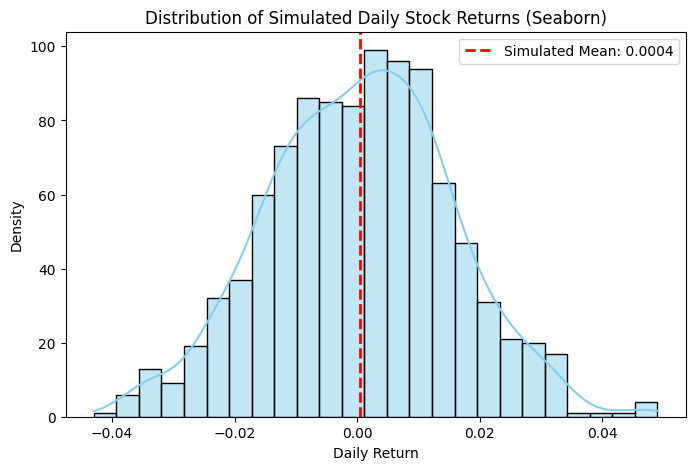

In [ ]:
# We are going to simulate stock returns
TARGET_MEAN_RETURN = 0.0005  # 0.05% expected daily return (mu)
TARGET_VOLATILITY = 0.015    # 1.5% daily volatility (sigma)
RNG_SEED = 2025 # For reproducibility

# Initialize the custom RNG
rng = np.random.default_rng(RNG_SEED)

# Generate standard normal data (1000 samples for 1000 trading days)
standard_normal_data = rng.standard_normal(size=1000)

# Apply the transformation (vectorized)
# R_custom = mu + sigma * X_standard
daily_returns = TARGET_MEAN_RETURN + TARGET_VOLATILITY * standard_normal_data

mean_simulated = np.mean(daily_returns)
stdev_simulated = np.std(daily_returns)

# Plotting the figure
plt.figure(figsize=(8, 5))

# Use sns.histplot for a modern histogram with a Kernel Density Estimate (KDE) curve
sns.histplot(daily_returns, bins=25, kde=True, color="skyblue", edgecolor="black", linewidth=1)

# Add the mean line for validation
plt.axvline(mean_simulated, color="red", linestyle="dashed", linewidth=2, label=f"Simulated Mean: {mean_simulated:.4f}")

plt.title("Distribution of Simulated Daily Stock Returns (Seaborn)")
plt.xlabel("Daily Return")
plt.ylabel("Density") # histplot uses Density on the y-axis when kde=True
plt.legend()

---
## 6. Image Processing with NumPy

In this exercise, we will use NumPy"s array manipulation and ufuncs to convert a three-color (RGB) image into a single-channel greyscale image. 

### **The Task**

1.  Load the provided three-color image data from the binary file **`nvddt.npy`** using `np.load()`.
2.  Define a function to convert the color image (shape `(H, W, 3)`) to a greyscale image (shape `(H, W)`). Use the **weighted average** formula:
    $$\text{Grayscale} = 0.2989 \cdot R + 0.5870 \cdot G + 0.1140 \cdot B$$
    Use NumPy"s vectorization for this calculation.
3.  Plot the resulting greyscale image using `plt.imshow()`, specifying `cmap="gray"`.

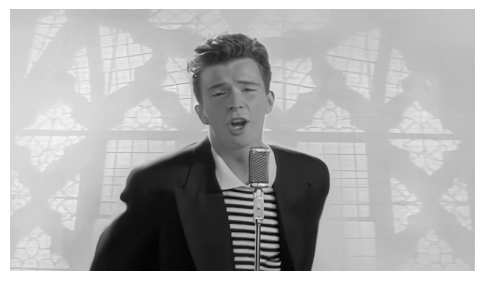

In [38]:
color_image = np.load("nvddt.npy")

# Function to convert RGB to Grayscale
def rgb_to_grayscale(rgb_array):
    """
    Converts an RGB image array to a grayscale array using the
    standard luminance formula (vectorized).
    """        
    # Slicing the channels (R, G, B are indices 0, 1, 2 along the last axis)
    R, G, B = rgb_array[..., 0], rgb_array[..., 1], rgb_array[..., 2]

    # Weighted average (Vectorized calculation)
    grayscale_image = 0.2989 * R + 0.5870 * G + 0.1140 * B
    return grayscale_image

# Apply the function
grayscale_result = rgb_to_grayscale(color_image)

# Plot the greyscale image
plt.figure(figsize=(6, 6))

# cmap="gray" is necessary for correct display of the single-channel array
plt.imshow(grayscale_result, cmap="gray")
plt.axis("off") 
plt.show()